## Red neuronal recurrente (RNN)
es una red especializada en el tratamiento de redes secuenciales (series de tiempo), incorporar una especie de memoria que capta valores pasados <br>
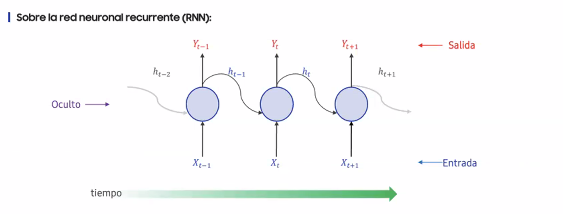

<br>
En cada tiempo hay diferentes instantes, aqui la red produce una salida 
Estado uculto - informacion del paso anterior (memoria interna) <br>

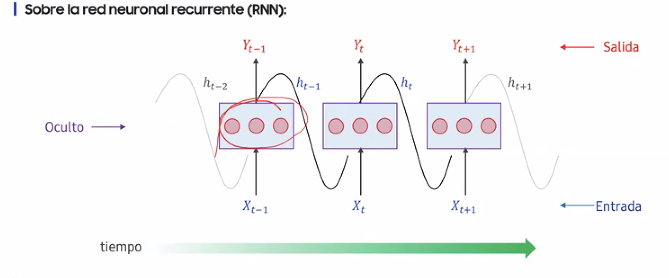 
<br>

# 1.1 Tipos de red 
- red neuronal recurrrente donde hay una secuencia de entrada y salida (many-two-many), las entradas de la red reciben varios elementos oredenados en el tiempo, para producir elementos de salida que dependen de valoras anteriores y entradas nuevas <br>
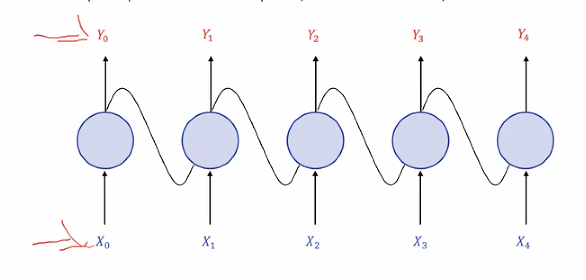<br>

- namy - two - one: este tipo de red consiste en tener varias entradas pero solo una salida <br>
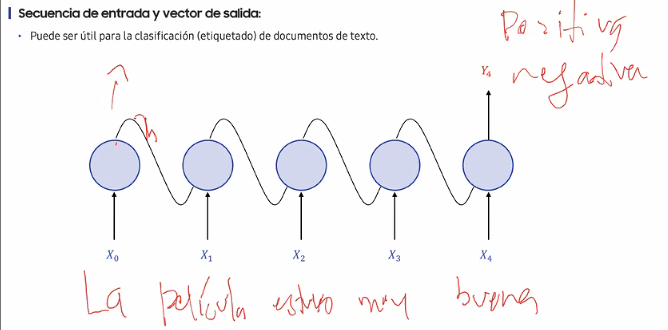 <br>

- one-two-mean: este tipo de red consiste en tener una sola entrada y una secuencia de salidas <br>
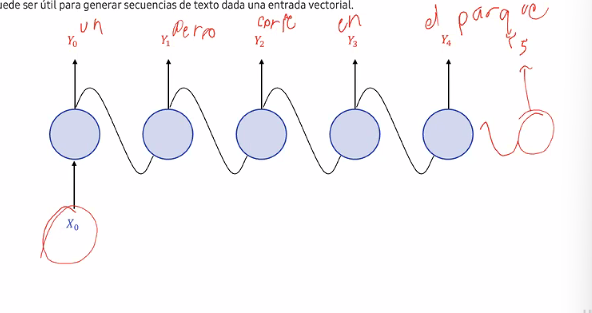


# Celula de memoria larga a corto plazo (LSTM)
mejora de la rnn ya que decide que informacion conserva, que olvida  y que muestra, nos ayudan a tener mas contexto ya que conserva informacion relebante 
<br>
$X_t$ -> entrada actual <br> 
$Y_{t-1}$ -> estado oculto <br>
$C_{t-1}$ -> estado de la celda anterio <br>
$c_t$ -> estado de la celula <br>
<br>
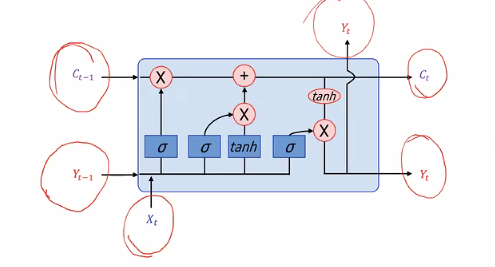
<br>
X -> multiplicacion elemento x elemento <br>
{+} -> suma elemento x elemento 
<br>
la celula se hace tres preguntas comunes 
- que debo olvidar
- que debo guradar 
- que debo mostrar 


In [ ]:
import numpy as mp
import matplotlib.pyplot as plt
import tensorflow as tf 
import glob 
import re  
import os ## interactuar entre capetas 

from tensorflow.keras.datasets import imdb   # reseñas de peliculas 
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
## construccion de red 
# y - reseñas positivas,negativas 
# x - 

##cargamos el conjunto de datos 
vocab_size = 10000  ## usamos las 10000 palabras mas comunes 
maxlen = 200 # defininos la longuitud maxima de cada reseña 

(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


c:\Users\6570\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [5]:
## nos aseguramos que las reseñas sean del mismo tamaño 
X_train = pad_sequences(X_train, maxlen=maxlen, padding='post',truncating='post')
X_test = pad_sequences(X_test, maxlen=maxlen, padding='post',truncating='post')

print('Forma X_train:', X_train.shape)
print('Forma X_test:', X_test.shape)

Forma X_train: (25000, 200)
Forma X_test: (25000, 200)


In [6]:
# Separamos reseñas para una demos 
n_demo = 5 
X_demo = X_test[:n_demo].copy()
y_demo = y_test[:n_demo].copy()

X_test_eval = X_test[n_demo:]
y_test_eval = y_test[n_demo:]

In [ ]:
# funcion para guardar los pesos 
def build_model(vocab_size,maxlen):
    #secuencia de keras 
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(maxlen,)),   #capa de input / , indica tupla de una dimensión / es para una sola reseña 
        tf.keras.layers.Embedding(input_dim= vocab_size,output_dim=64),   # capa de embeding / representar las palabras en un vector denso  
        tf.keras.layers.LSTM(64),    #capa de long short / lee palabra a palabra y mantiene el resumen
        tf.keras.layers.Dense(1,activation='sigmoid')    
    ])

    model.compile(
        optimizer = 'Adam',
        loss = 'binary_crossentropy',
        metrics = ['accuracy']   
    )

    return model 

In [ ]:
model_imdb = build_model(vocab_size,maxlen)
print('\nResumen del modelo :')
model_imdb.summary()

In [ ]:
checkpoints_dir = './checkpoints_imdb'
os.makedirs(checkpoints_dir, exist_ok=True)
checkpoints_path = os.path.join(checkpoints_dir, 'epoca_{epoch:02d}.weights.h5') #ruta para guardar el checkpoint 

#objeto de keras que crea un callback / que nombre poner y como guardarlo 
checkpoints_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = checkpoints_path ,    #ruta donde se va a ir guardando el archivo
    save_weights_only = True,
    save_freq = 'epoch', #Guardamos los peso 
    verbose=1 
) 


In [16]:
# Entrenamiento del modelo 
EPOCHS = 5 
seed = 42
tf.keras.utils.set_random_seed(seed) # le decimos a keras que use la semilla establecida arriba 
## Entramiento 
history = model_imdb.fit(
    X_train,y_train,
    validation_split = 0.2,  #usa el 20% para validar en las epocas
    epochs = EPOCHS,
    batch_size= 64, # nuemro de veces que el modelo recore el conjunto de datos 
    callbacks = [checkpoints_callback], 
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5210 - loss: 0.6925
Epoch 1: saving model to ./checkpoints_imdb\epoca_01.weights.h5

Epoch 1: finished saving model to ./checkpoints_imdb\epoca_01.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - accuracy: 0.5428 - loss: 0.6879 - val_accuracy: 0.6328 - val_loss: 0.6556
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6113 - loss: 0.6590
Epoch 2: saving model to ./checkpoints_imdb\epoca_02.weights.h5

Epoch 2: finished saving model to ./checkpoints_imdb\epoca_02.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.5860 - loss: 0.6666 - val_accuracy: 0.5274 - val_loss: 0.6837
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5848 - loss: 0.6676
Epoch 3: saving model to ./checkpoints_imdb\epoca_03.weights.h5

Epoch 3: finished saving model to ./checkpoints_imdb\epoca_03.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.6155 - loss: 0.6445 - val_accur

In [17]:
loss,acc = model_imdb.evaluate(X_test_eval, y_test_eval, verbose=1)
print(f'\nPerdida en test: {loss:.4f}')
print(f'\nAccuracy en test: {acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.5483 - loss: 0.6741

Perdida en test: 0.6741

Accuracy en test: 0.5483


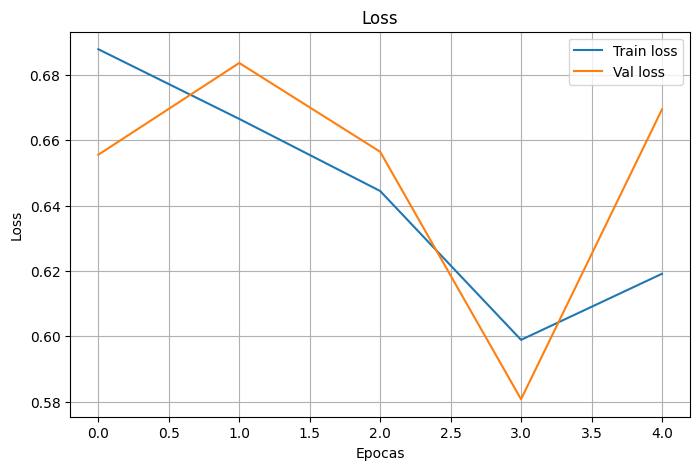

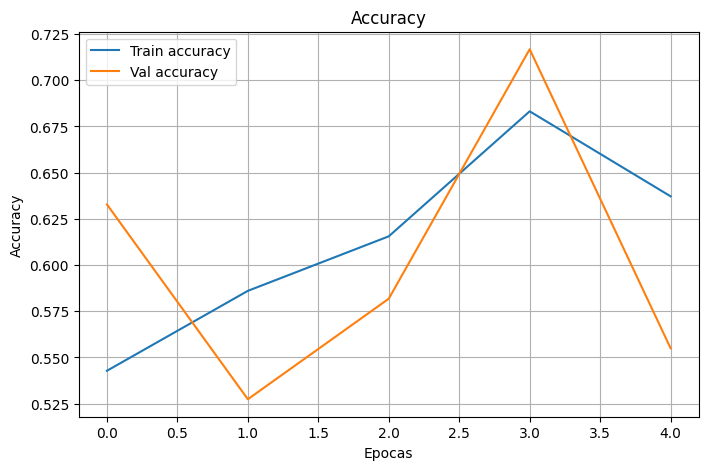

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Val loss')
plt.title('Loss')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Epocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [19]:
# Cargar checkpoints guardados 
checkpoints_files = glob.glob(os.path.join(checkpoints_dir,'epoca_*.weights.h5')) # Buscamos los archivos 

if checkpoints_files: 
    checkpoints_files.sort(key= lambda x: int(re.search(r'epoca_(\d+)',x).group(1)))
    ultimo_checkpoint = checkpoints_files[-1]
    print('\nUltimo checkpoinnt encontrado:', ultimo_checkpoint)

    model_loaded = build_model(vocab_size,maxlen)
    model_loaded.load_weights(ultimo_checkpoint)     #Pesos entrenados 
    print('\nPesoscragados correctamente. ')

else:
    model_load = None 
    print('\nNo se encontraton checkpoint')


Ultimo checkpoinnt encontrado: ./checkpoints_imdb\epoca_05.weights.h5

Pesoscragados correctamente. 


c:\Users\6570\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
## Evaluacion para checar que funcione con el modelo ya cargado 

loss_loaded, acc_loaded = model_loaded.evaluate(X_test_eval,y_test_eval,verbose=1) 
print(f'Modelo cargado - loss en test: {loss_loaded:.4f}')
print(f'Modelo cargado - accuracy en test: {acc_loaded:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5483 - loss: 0.6741
Modelo cargado - loss en test: 0.6741
Modelo cargado - accuracy en test: 0.5483


In [24]:
pred_probs = model_loaded.predict(X_demo, verbose=0)  #resultados entre 0-1 
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

for i in range(len(X_demo)):  #imprimimos etiquetas 
    print('\n'+'-'*80)
    print(f'Reseña_{i+1}')
    print('-'*80)
    print('\nEtiqueta real:', y_demo[i],'-->','Positiva' if y_demo[i] == 1 else 'Negativa')
    print('Probababilidad de ser positiva:',pred_probs[i][0])
    print('Etiqueta predicha:', pred_labels[i],'-->','Positiva' if pred_labels[i] == 1 else 'Negativa')



--------------------------------------------------------------------------------
Reseña_1
--------------------------------------------------------------------------------

Etiqueta real: 0 --> Negativa
Probababilidad de ser positiva: 0.45981756
Etiqueta predicha: 0 --> Negativa

--------------------------------------------------------------------------------
Reseña_2
--------------------------------------------------------------------------------

Etiqueta real: 1 --> Positiva
Probababilidad de ser positiva: 0.54686344
Etiqueta predicha: 1 --> Positiva

--------------------------------------------------------------------------------
Reseña_3
--------------------------------------------------------------------------------

Etiqueta real: 1 --> Positiva
Probababilidad de ser positiva: 0.8105643
Etiqueta predicha: 1 --> Positiva

--------------------------------------------------------------------------------
Reseña_4
----------------------------------------------------------------------

In [26]:
## Version modifica/ Nuevo modelo 

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64),
    tf.keras.layers.LSTM(
        64,dropout=0.2,
        recurrent_dropout=0.2, # se hacen en los nodos internos (salida)
        
    ),
    tf.keras.layers.Dropout(0.3),  # apaga los nodos de entrada 
    tf.keras.layers.Dense(1,activation='sigmoid')
    ])

model_2.compile(
    optimizer='Adam',
    loss= 'binary_crossentropy',
    metrics= ['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',  #variable a observar
    patience=2,  # variable a observar antes de detener el entrenamiento
    restore_best_weights=True, # recupera los mejores pesos de la ultima epoca no necesariamente la ultima
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath= 'mejor_modelo_lstm.keras', # Guardamos el mejor modelo (completo) 
    monitor= 'val_loss',
    save_best_only=True,
    verbose=1
)

In [32]:
history_2 = model_2.fit(
    X_train,y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop,checkpoint],
    verbose= 1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5095 - loss: 0.6927
Epoch 1: val_loss improved from None to 0.68374, saving model to mejor_modelo_lstm.keras

Epoch 1: finished saving model to mejor_modelo_lstm.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 99ms/step - accuracy: 0.5242 - loss: 0.6904 - val_accuracy: 0.5364 - val_loss: 0.6837
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5736 - loss: 0.6776
Epoch 2: val_loss improved from 0.68374 to 0.61864, saving model to mejor_modelo_lstm.keras

Epoch 2: finished saving model to mejor_modelo_lstm.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.5836 - loss: 0.6603 - val_accuracy: 0.6130 - val_loss: 0.6186
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6773 - loss: 0.5936
Epoch 3: val_loss improved from 0.61864 to 0.54472, saving model to mejor_modelo_lstm.keras

Epoch 3: finished saving model to mejor_modelo_lstm.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - ac

In [33]:
best_model =tf.keras.models.load_model('mejor_modelo_lstm.keras')
test_loss, test_acc = best_model.evaluate(X_test_eval,y_test_eval,verbose=1) 

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.8232 - loss: 0.4460


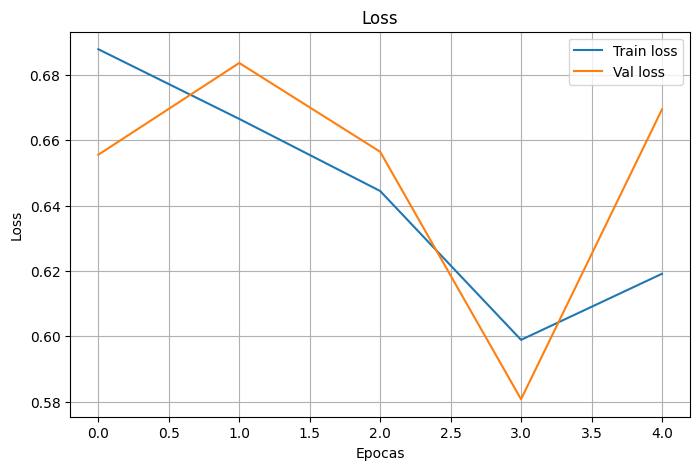

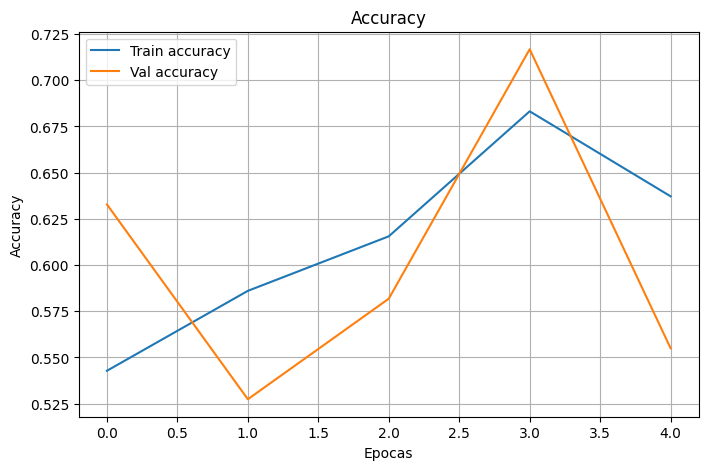

In [34]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Val loss')
plt.title('Loss')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Epocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()